,Entradas,Ventas,Merma,Existencia_final,Reponer
Fruta,,,,,
Mango,28,11,1,26,False
Manzana,25,12,0,31,False
Platano,18,12,1,19,True


Unidades vendidas: 35
Unidades de merma: 2


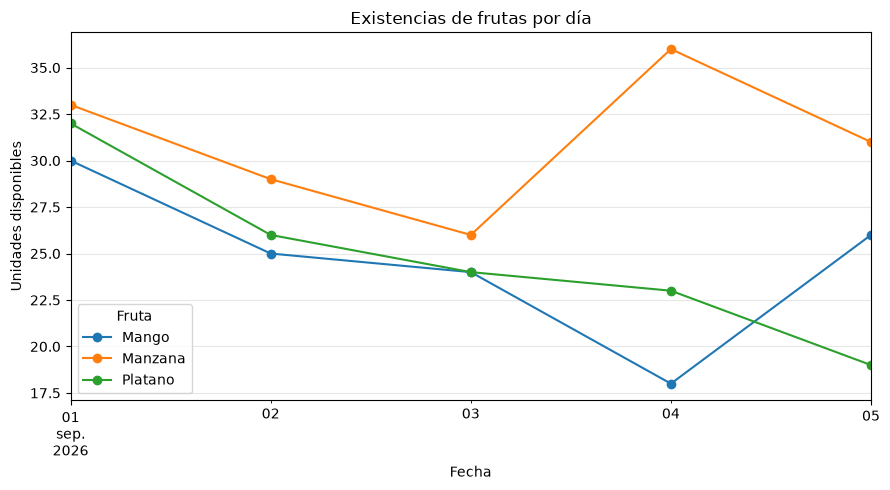

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Existencias disponibles antes del primer movimiento
stock_inicial = {
    "Mango": 10,
    "Manzana": 18,
    "Platano": 14,
}

# Movimientos ficticios del 1 al 5 de septiembre de 2026
movimientos = [
    ("2026-09-01", "Mango", "Entrada", 20),
    ("2026-09-01", "Manzana", "Entrada", 15),
    ("2026-09-01", "Platano", "Entrada", 18),
    ("2026-09-02", "Mango", "Venta", 5),
    ("2026-09-02", "Manzana", "Venta", 4),
    ("2026-09-02", "Platano", "Venta", 6),
    ("2026-09-03", "Mango", "Merma", 1),
    ("2026-09-03", "Manzana", "Venta", 3),
    ("2026-09-03", "Platano", "Venta", 2),
    ("2026-09-04", "Mango", "Venta", 6),
    ("2026-09-04", "Manzana", "Entrada", 10),
    ("2026-09-04", "Platano", "Merma", 1),
    ("2026-09-05", "Mango", "Entrada", 8),
    ("2026-09-05", "Manzana", "Venta", 5),
    ("2026-09-05", "Platano", "Venta", 4),
]

df = pd.DataFrame(
    movimientos,
    columns=["Fecha", "Fruta", "Movimiento", "Cantidad"]
)

df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values(["Fecha", "Fruta"]).reset_index(drop=True)

# Las entradas suman; las ventas y mermas restan
signo_movimiento = {
    "Entrada": 1,
    "Venta": -1,
    "Merma": -1,
}

df["Variacion"] = (
    df["Cantidad"] * df["Movimiento"].map(signo_movimiento)
)

df["Existencia"] = (
    df["Fruta"].map(stock_inicial)
    + df.groupby("Fruta")["Variacion"].cumsum()
)

# Verifica que ningún movimiento deje existencias negativas
assert (df["Existencia"] >= 0).all(), "Hay existencias negativas."

# Separa los tipos de movimiento para resumirlos
df["Entrada"] = df["Cantidad"].where(df["Movimiento"] == "Entrada", 0)
df["Venta"] = df["Cantidad"].where(df["Movimiento"] == "Venta", 0)
df["Merma"] = df["Cantidad"].where(df["Movimiento"] == "Merma", 0)

resumen = df.groupby("Fruta").agg(
    Entradas=("Entrada", "sum"),
    Ventas=("Venta", "sum"),
    Merma=("Merma", "sum"),
    Existencia_final=("Existencia", "last"),
)

resumen["Reponer"] = resumen["Existencia_final"] < 20

display(resumen)

print(f"Unidades vendidas: {df['Venta'].sum()}")
print(f"Unidades de merma: {df['Merma'].sum()}")

# Gráfica de existencias al cierre de cada día
stock_diario = df.pivot(
    index="Fecha",
    columns="Fruta",
    values="Existencia"
)

stock_diario.plot(marker="o", figsize=(9, 5))
plt.title("Existencias de frutas por día")
plt.xlabel("Fecha")
plt.ylabel("Unidades disponibles")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Fruta")
plt.tight_layout()
plt.show()